## Monte Carlo - Forecasting Stock Prices - Part III

*Suggested Answers follow (usually there are multiple ways to solve a problem in Python).*

Forecasting Future Stock Prices – continued:

In [1]:
import numpy as np  
import pandas as pd  
from pandas_datareader import data as wb  
import matplotlib.pyplot as plt  
from scipy.stats import norm
import yfinance as yf
%matplotlib inline

ticker = 'MSFT' 
data = pd.DataFrame()
data[ticker] = yf.download(ticker, start='2000-1-1', auto_adjust=False)['Adj Close']

log_returns = np.log(1 + data.pct_change())
u = log_returns.mean()
var = log_returns.var()
drift = u - (0.5 * var)
stdev = log_returns.std()

drift.values
stdev.values

t_intervals = 250
iterations = 10

daily_returns = np.exp(drift.values + stdev.values * norm.ppf(np.random.rand(t_intervals, iterations)))

[*********************100%***********************]  1 of 1 completed


***

Create a variable S0 equal to the last adjusted closing price of Microsoft. Use the “iloc” method.

In [2]:
S0 = data.iloc[-1]
S0

MSFT    517.809998
Name: 2025-10-31 00:00:00, dtype: float64

Create a variable price_list with the same dimension as the daily_returns matrix. 

In [3]:
price_list = np.zeros_like(daily_returns)
price_list

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Set the values on the first row of the price_list array equal to S0.

In [4]:
price_list[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

Create a loop in the range (1, t_intervals) that reassigns to the price in time t the product of the price in day (t-1) with the value of the daily returns in t.

In [6]:
price_list[0] = S0
price_list

array([[517.80999756, 517.80999756, 517.80999756, ..., 517.80999756,
        517.80999756, 517.80999756],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

In [7]:
for t in range(1, t_intervals):
    price_list[t] = price_list[t - 1] * daily_returns[t]

In [8]:
price_list

array([[517.80999756, 517.80999756, 517.80999756, ..., 517.80999756,
        517.80999756, 517.80999756],
       [511.7679438 , 498.85984769, 511.66589907, ..., 509.6007373 ,
        508.09762621, 512.17143769],
       [524.96466946, 490.55327841, 515.65976219, ..., 515.30774308,
        522.27916398, 514.84998682],
       ...,
       [518.18659005, 485.82302038, 735.06386517, ..., 602.54836379,
        750.58181128, 602.71969723],
       [523.6254937 , 511.72557816, 731.4568932 , ..., 600.78508152,
        737.07254842, 620.72832726],
       [521.95748085, 515.30368623, 754.00559973, ..., 603.00227994,
        720.82077929, 629.23337871]])

Finally, plot the obtained price list data.

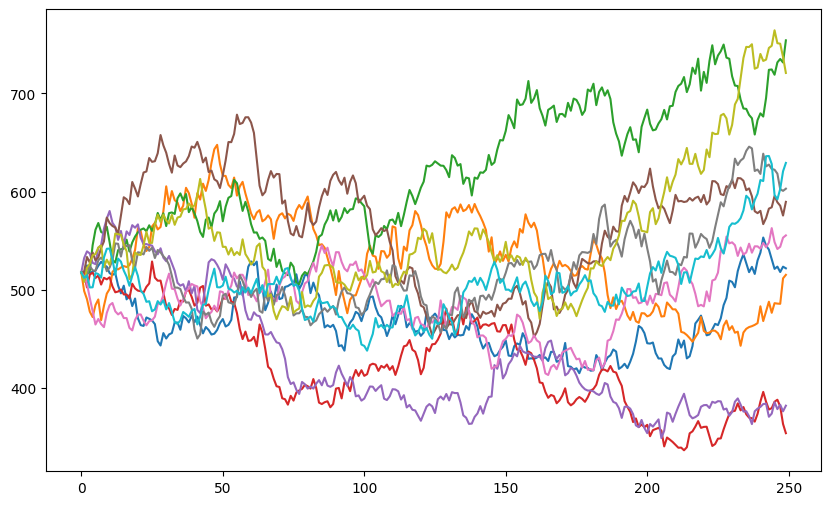

In [9]:
plt.figure(figsize=(10,6))
plt.plot(price_list);